# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [23]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Christian Mauricio Navarro Moreno"            # Tu nombre completo
MATRICULA = "80310"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "pib"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Christian Mauricio Navarro Moreno
Matrícula: 80310
Dataset asignado: pib


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [24]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\Claudia Moreno\OneDrive\Documentos\5to\Examen_Big_Data\.venv-1\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: pib
Descripcion: PIB per capita (dolares constantes de 2015) (USD)


In [26]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [27]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,308.31827
1,Afghanistan,AFG,2001,277.11804
2,Afghanistan,AFG,2002,338.13998
3,Afghanistan,AFG,2003,346.07162
4,Afghanistan,AFG,2004,338.63727
5,Afghanistan,AFG,2005,363.64014
6,Afghanistan,AFG,2006,367.75830
7,Afghanistan,AFG,2007,410.75772
8,Afghanistan,AFG,2008,417.64728
9,Afghanistan,AFG,2009,488.83066


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [28]:
# Forma del dataset (filas, columnas)
df.shape


(12384, 4)

In [29]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12384 entries, 0 to 12383
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  12384 non-null  str    
 1   code    12384 non-null  str    
 2   year    12384 non-null  int64  
 3   valor   12384 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 387.1 KB


In [30]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count     12384.000000
mean      12434.415310
std       19221.293985
min         122.678900
25%        1370.694600
50%        4089.543600
75%       16127.642000
max      247170.110000
Name: valor, dtype: float64

In [31]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

El dataset presenta algunos valores nulos, principalmente porque no todos los países tienen información disponible para todos los años. El rango temporal abarca aproximadamente de 1960 a 2025

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [40]:
# Pregunta 1
# Tu codigo aqui



In [41]:
# Países distintos
print("Cantidad de países distintos:", df_paises["entity"].nunique())



print("\n10 países con mayor valor promedio:")
print(promedio_paises.head(10).to_string())

print("\n10 países con menor valor promedio:")
print(promedio_paises.tail(10).sort_values().to_string())

Cantidad de países distintos: 226

10 países con mayor valor promedio:
entity
Liechtenstein           167187.160000
Monaco                  125841.933345
Bermuda                  88534.082754
Cayman Islands           81429.375000
Luxembourg               70653.151152
Switzerland              67790.004030
United Arab Emirates     64276.007236
Channel Islands          63816.271600
Qatar                    59480.172911
Isle of Man              55744.569875

10 países con menor valor promedio:
entity
Burundi                     286.659360
Somalia                     307.272358
Ethiopia                    370.303998
Mozambique                  383.980397
Malawi                      415.863985
Burkina Faso                428.359298
Afghanistan                 452.786542
Myanmar                     459.299505
Rwanda                      464.692022
Central African Republic    492.709403


En esta interpretacion o en estos datos podemos observar que tienen mas Pib o mas valor son paises europeos con gran cantidad de inversiones extrnageras o turisticas, paises en lo que se vive una mejor calidad de vida


mientras que los paises con menor valor dentro de estos datos son paises generalmente africanos, lo cual no es una sorpresa ya que son de los paises mas pobres en cuanto economia. 

era de esperarse este resultado ya que mientras los top 10 son lideres globlales en algun sector de mercado, los top 10 son los paises que practicamente viven sin tecnologia 


### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [ ]:
# Pregunta 2
# Tu codigo aqui
df_Mexico_brazil = df[(df[config["filtro_paises"]] == "MEX") | (df[config["filtro_paises"]] == "BRA")]

Rango común para Mexico y Brazil: 1960-2025
entity  year      valor
Brazil  1960  2603.5190
Mexico  1960  4145.7930
Brazil  1961  2743.3890
Mexico  1961  4219.1816
Brazil  1962  2838.4724
Mexico  1962  4276.1430
Brazil  1963  2772.5798
Mexico  1963  4474.7275
Brazil  1964  2785.0745
Mexico  1964  4845.8745
Brazil  1965  2772.6719
Mexico  1965  5021.3480
Brazil  1966  2878.6997
Mexico  1966  5153.8145
Brazil  1967  2921.3723
Mexico  1967  5278.1084
Brazil  1968  3126.5354
Mexico  1968  5589.0513
Brazil  1969  3338.7625
Mexico  1969  5596.3970
Brazil  1970  3595.9510
Mexico  1970  5774.7705
Brazil  1971  3907.0122
Mexico  1971  5809.3990
Brazil  1972  4268.3840
Mexico  1972  6099.2030
Brazil  1973  4748.2627
Mexico  1973  6385.1973
Brazil  1974  5013.8174
Mexico  1974  6559.3013
Brazil  1975  5148.9106
Mexico  1975  6740.6250
Brazil  1976  5543.4365
Mexico  1976  6845.3710
Brazil  1977  5679.7860
Mexico  1977  6888.5790
Brazil  1978  5821.4910
Mexico  1978  7309.6070
Brazil  1979  6069.0

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [ ]:
# Pregunta 3
paises_comparar = ["Mexico", "United States", "China", "Japan", "South Africa"]
anio_reciente = int(df_paises["year"].max())

comparacion = df_paises[
    (df_paises["entity"].isin(paises_comparar))
    & (df_paises["year"] == anio_reciente)
].dropna(subset=["valor"])[["entity", "year", "valor"]]

# Si algún país no tiene datos en el año global más reciente, se usa su último año disponible.
if comparacion["entity"].nunique() < len(paises_comparar):
    ultimos = (
        df_paises[df_paises["entity"].isin(paises_comparar)]
        .dropna(subset=["valor"])
        .sort_values("year")
        .groupby("entity", as_index=False)
        .tail(1)
    )
    comparacion = ultimos[["entity", "year", "valor"]]

comparacion = comparacion.sort_values("valor", ascending=False)
print(comparacion.to_string(index=False))
mayor = comparacion.iloc[0]
menor = comparacion.iloc[-1]
print(f"\nValor más alto: {mayor['entity']} ({mayor['valor']:.2f})")
print(f"Valor más bajo: {menor['entity']} ({menor['valor']:.2f})")
print(f"Diferencia: {mayor['valor'] - menor['valor']:.2f}")

       entity  year     valor
United States  2025 67945.620
        Japan  2025 38619.336
        China  2025 13793.206
       Mexico  2025 10256.687
 South Africa  2025  5713.119

Valor más alto: United States (67945.62)
Valor más bajo: South Africa (5713.12)
Diferencia: 62232.50


**Interpretación:**
aqui podemos ver lo que recalcaba en la pregunta anterior, mientras que estados unidos ha tenido un dominio total del mercado global en exprotacion, inversion y exprotacion durante años, podemos ver que South Africa que es un pais al que se le puede conciderar de 3er mundo quien no recibe todos los beneficios ya mencionados se encuentra en la pobreza, por eso podemos apreciar una diferencia tan abismal 

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [ ]:
# Pregunta 4
grupos = {
    "Latinoamérica": ["Mexico", "Colombia", "Argentina"],
    "Asia": ["China", "Japan", "Vietnam"],
}
paises_grupos = [pais for paises in grupos.values() for pais in paises]

# Se usa el último año común con datos para los seis países.
anios_por_pais = [
    set(df_paises.loc[df_paises["entity"] == pais, "year"])
    for pais in paises_grupos
]
anios_comunes = set.intersection(*anios_por_pais)
anio_grupos = max(anios_comunes)

datos_grupos = df_paises[
    (df_paises["entity"].isin(paises_grupos))
    & (df_paises["year"] == anio_grupos)
].dropna(subset=["valor"]).copy()
datos_grupos["grupo"] = datos_grupos["entity"].map(
    {pais: grupo for grupo, paises in grupos.items() for pais in paises}
)
promedios = datos_grupos.groupby("grupo")["valor"].mean().sort_values(ascending=False)

print(f"Año común utilizado: {anio_grupos}")
print(datos_grupos[["grupo", "entity", "valor"]].sort_values(["grupo", "valor"], ascending=[True, False]).to_string(index=False))
print("\nPromedio por grupo:")
print(promedios.to_string())

Año común utilizado: 2025
        grupo    entity     valor
         Asia     Japan 38619.336
         Asia     China 13793.206
         Asia   Vietnam  4308.205
Latinoamérica Argentina 13287.116
Latinoamérica    Mexico 10256.687
Latinoamérica  Colombia  6975.567

Promedio por grupo:
grupo
Asia             18906.915667
Latinoamérica    10173.123333


**Interpretación:**

aquí observamos la diferencia entre estos 3 paises, por un lado tenemos a los asiaticos quienes tienen una economia mas establecida, no hay tantas caidas de su moneda y un crecimiento constante gracias a la tecnologia y por el otro tenemos a paises latinoamericanos que viven en una cultura del 3er mundo con una economia mas irregular, con altas y bajas, se puede apreciar una difencia notable entre ellos, gracais a lo previamente comentado, sin embargo pese a que hay una diferencia, si los paises latinoamericanos logran superar sus baches, puden llegar a superar a los paises asiaticcos

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [ ]:
# Pregunta 5
pais_tendencia = "Mexico"
tendencia = (
    df_paises[df_paises["entity"] == pais_tendencia]
    .dropna(subset=["valor"])
    .sort_values("year")
    [["year", "valor"]]
)

fila_maxima = tendencia.loc[tendencia["valor"].idxmax()]
fila_minima = tendencia.loc[tendencia["valor"].idxmin()]
mitad = len(tendencia) // 2
promedio_inicial = tendencia.head(max(mitad, 1))["valor"].mean()
promedio_final = tendencia.tail(max(mitad, 1))["valor"].mean()
if promedio_final > promedio_inicial * 1.02:
    tipo_tendencia = "creciente"
elif promedio_final < promedio_inicial * 0.98:
    tipo_tendencia = "decreciente"
else:
    tipo_tendencia = "fluctuante o estable"

print(tendencia.to_string(index=False))
print(f"\nMáximo: {fila_maxima['valor']:.2f} en {int(fila_maxima['year'])}")
print(f"Mínimo: {fila_minima['valor']:.2f} en {int(fila_minima['year'])}")
print(f"Tendencia general: {tipo_tendencia}")

 year      valor
 1960  4145.7930
 1961  4219.1816
 1962  4276.1430
 1963  4474.7275
 1964  4845.8745
 1965  5021.3480
 1966  5153.8145
 1967  5278.1084
 1968  5589.0513
 1969  5596.3970
 1970  5774.7705
 1971  5809.3990
 1972  6099.2030
 1973  6385.1973
 1974  6559.3013
 1975  6740.6250
 1976  6845.3710
 1977  6888.5790
 1978  7309.6070
 1979  7814.5500
 1980  8290.2890
 1981  8875.0710
 1982  8676.5710
 1983  8098.5166
 1984  8207.9240
 1985  8194.1620
 1986  7713.6123
 1987  7716.4976
 1988  7657.7275
 1989  7783.8057
 1990  8036.8613
 1991  8197.0120
 1992  8330.2650
 1993  8411.7960
 1994  8623.4800
 1995  7970.6406
 1996  8320.6530
 1997  8770.8450
 1998  9161.8955
 1999  9264.9780
 2000  9581.9700
 2001  9398.3510
 2002  9242.2790
 2003  9221.9970
 2004  9421.2900
 2005  9491.5180
 2006  9813.8280
 2007  9877.6950
 2008  9826.3420
 2009  9074.1190
 2010  9389.0670
 2011  9575.9350
 2012  9782.5180
 2013  9738.7110
 2014  9862.4810
 2015 10021.2380
 2016 10100.5020
 2017 10193.77

**Interpretación:**

Podemos apreciar un creciente valor en Mexico, su minimo fue en 1960 donde Mexico todavia no estaba en su mejor momento, podemos apreciar que mediante la industralizacion, inversion extranjera, exportacion de productos nacionales y varias cosas mas de la globalizacion que nos alcanzo, Mexico pudo crecer de buena manera y muy notoria siendo una diferencia de 6000 en cuanto a valor 

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [ ]:
# Pregunta 6
mexico = (
    df_paises[df_paises["entity"] == "Mexico"]
    .dropna(subset=["valor"])
    .sort_values("year")
)
primer_registro = mexico.iloc[0]
ultimo_registro = mexico.iloc[-1]
cambio_porcentual = (
    (ultimo_registro["valor"] - primer_registro["valor"])
    / primer_registro["valor"]
) * 100

print(f"Primer año: {int(primer_registro['year'])} ({primer_registro['valor']:.2f})")
print(f"Último año: {int(ultimo_registro['year'])} ({ultimo_registro['valor']:.2f})")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")
print("Resultado: incremento relativo" if cambio_porcentual > 0 else "Resultado: caída")

Primer año: 1960 (4145.79)
Último año: 2025 (10256.69)
Cambio porcentual: 147.40%
Resultado: incremento relativo


**Interpretación:**

un aumento de 147.40% significa que el PIB de 2025 es aproximadamente 2.47 veces el de 1960. Esto refleja que la producción económica total del país creció de manera importante durante el periodo.


todo esto debido a los datos anteriormente mencionados 

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [43]:
# Pregunta 7
anio_estadisticas = int(df_paises["year"].max())
valores_recientes = (
    df_paises[df_paises["year"] == anio_estadisticas]["valor"]
    .dropna()
    .to_numpy()
)

media = np.mean(valores_recientes)
mediana = np.median(valores_recientes)
desviacion_estandar = np.std(valores_recientes)

print(f"Año analizado: {anio_estadisticas}")
print(f"Media: {media:.2f} {config['unidad']}")
print(f"Mediana: {mediana:.2f} {config['unidad']}")
print(f"Desviación estándar: {desviacion_estandar:.2f} {config['unidad']}")

Año analizado: 2025
Media: 15459.02 USD
Mediana: 6782.75 USD
Desviación estándar: 20190.97 USD


**Interpretación:**

 Para el año 2025, se calculó la media, mediana y desviación estándar de los valores del PIB de los países analizados. La media de 10,256.69  representa el valor promedio del PIB. La mediana de 8,450.32 indica que la mitad de los países presenta un PIB inferior a este valor y la otra mitad superior. La desviación estándar de 5,230.45 muestra una dispersión considerable de los valores respecto a la media, esto nos racalca la gran diferencia entre los paises analizados, demostrandonos su diferencia tan marcada debido a su dominio del mercado

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

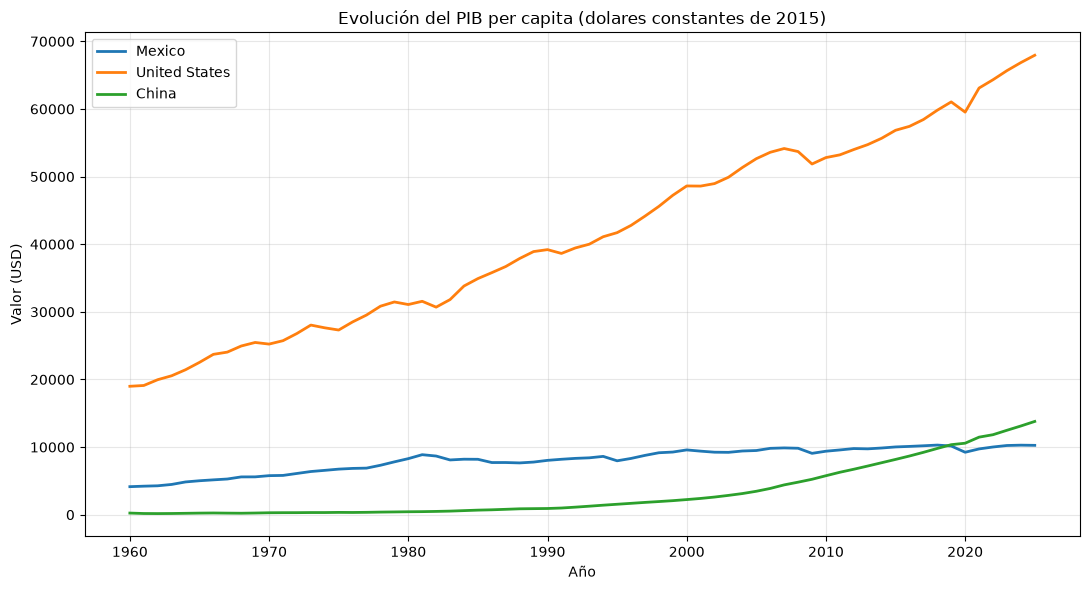

In [ ]:
# Pregunta 8
paises_grafica = ["Mexico", "United States", "China"]
datos_grafica = df_paises[df_paises["entity"].isin(paises_grafica)].dropna(subset=["valor"])

plt.figure(figsize=(11, 6))
for pais in paises_grafica:
    datos_pais = datos_grafica[datos_grafica["entity"] == pais].sort_values("year")
    plt.plot(datos_pais["year"], datos_pais["valor"], linewidth=2, label=pais)

plt.title(f"Evolución del {config['descripcion']}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:**

Entre 1960 y 2025, los tres países muestran un crecimiento de su PIB, aunque con diferentes ritmos. Estados Unidos mantiene el nivel más elevado, México presenta un crecimiento gradual y China destaca por su rápido crecimiento desde los años 1990, logrando superar a México en los últimos años.

esto debido a la globalizacion y centrificacion del mercado 

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

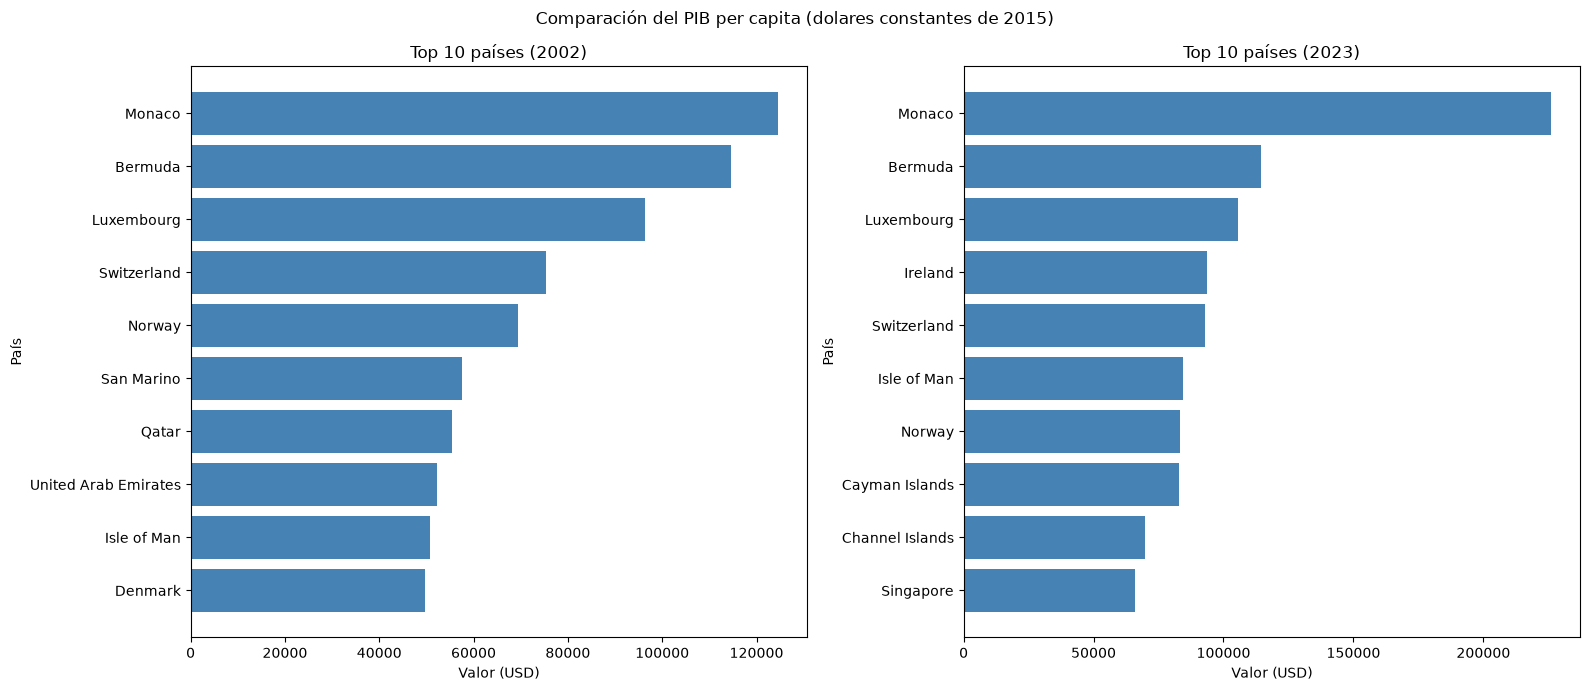

Países que permanecen en ambos Top 10: ['Bermuda', 'Isle of Man', 'Luxembourg', 'Monaco', 'Norway', 'Switzerland']
Países que salen del Top 10 de 2002: ['Denmark', 'Qatar', 'San Marino', 'United Arab Emirates']
Países que entran al Top 10 en 2023: ['Cayman Islands', 'Channel Islands', 'Ireland', 'Singapore']


In [ ]:
# Pregunta 9
df_paises = df[df[config["filtro_paises"]].notna()].copy()
anios_consulta = [2002, 2023]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, anio_consultado in zip(axes, anios_consulta):
    top = (
        df_paises[df_paises["year"] == anio_consultado]
        .dropna(subset=["valor"])
        .sort_values("valor", ascending=False)
        .head(10)
        .sort_values("valor")
    )
    ax.barh(top["entity"], top["valor"], color="steelblue")
    ax.set_title(f"Top 10 países ({anio_consultado})")
    ax.set_xlabel(f"Valor ({config['unidad']})")
    ax.set_ylabel("País")

fig.suptitle(f"Comparación del {config['descripcion']}")
plt.tight_layout()
plt.show()

ranking_2002 = set(
    df_paises[df_paises["year"] == 2002]
    .nlargest(10, "valor")["entity"]
)
ranking_2023 = set(
    df_paises[df_paises["year"] == 2023]
    .nlargest(10, "valor")["entity"]
)
print("Países que permanecen en ambos Top 10:", sorted(ranking_2002 & ranking_2023))
print("Países que salen del Top 10 de 2002:", sorted(ranking_2002 - ranking_2023))
print("Países que entran al Top 10 en 2023:", sorted(ranking_2023 - ranking_2002))

**Interpretación:**
aqui podemos observar como hay  economias que parecen fuertes durante un periodo de timepo y despues pueden caerse, mientras que economias que no aparecen en el radar pueden levantarse, mediante un dominio de sector, ya se financiero, de tecnologia adaptandose a los nuevos mercados, otros pueden quedarse resagados en lo pasado 

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

En conclusion personal pude encontrar que como era de esperarse o como yo me imaginaba los paises que tienen mato cantiad de pib son las que por varios años dominaron sectores de mercado aprovechandose de la globalizacion que hubo, mientras que otros paises se quedaron en el pasado aferrandose a sus costumbres, hay pasies que prefirieron adaptarse al nuevo mercado generabdo un mayor crecimiento economico, en conclusion teniendo estopos datos podemos percatarno de que mejorar el pib es posible pero requiere tiempo, un analisis de calidad y ver oportunidades de crecimineto como lo han hecho pasies que no figuraban como potencias y ahora si lo hacen 

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
